<a href="https://colab.research.google.com/github/bharathbingi5/employee-salary-prediction/blob/main/Copy_of_intenship_salary_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df =pd.read_csv('/content/Employers_data.csv')
df

,Employee_ID,Name,Age,Gender,Department,Job_Title,Experience_Years,Education_Level,Location,Salary
0,1,Merle Ingram,24,Female,Engineering,Engineer,1,Master,Austin,90000
1,2,John Mayes,56,Male,Sales,Executive,33,Master,Seattle,195000
2,3,Carlos Wille,21,Male,Engineering,Intern,1,Bachelor,New York,35000
3,4,Michael Bryant,30,Male,Finance,Analyst,9,Bachelor,New York,75000
4,5,Paula Douglas,25,Female,HR,Analyst,2,Master,Seattle,70000
...,...,...,...,...,...,...,...,...,...,...
9995,9996,Thomas Rossin,51,Male,Sales,Executive,28,Master,Austin,185000
9996,9997,Christie King,36,Female,Sales,Executive,9,PhD,San Francisco,165000
9997,9998,Alfred Keller,57,Male,Sales,Executive,30,PhD,New York,200000
9998,9999,Margaret Gomez,37,Female,Engineering,Manager,14,Master,New York,135000


In [6]:
from sklearn.preprocessing import LabelEncoder
import IPython.display as display # Ensure display is imported, in case it wasn't already or was overridden

# Create a dictionary to store label encoders for each categorical column
label_encoders = {}

# Dynamically identify and apply Label Encoding to each object-type column
# This ensures only columns that are still of object type are encoded.
for col in df.select_dtypes(include='object').columns:
    label_encoders[col] = LabelEncoder()
    # Fit and transform the column
    df[col] = label_encoders[col].fit_transform(df[col])
    print(f"Encoded column '{col}'.")

# Display the updated dtypes to confirm encoding
print("DataFrame dtypes after label encoding:")
display.display(df.dtypes) # Corrected call to display.display()

Encoded column 'Name'.
Encoded column 'Gender'.
Encoded column 'Department'.
Encoded column 'Job_Title'.
Encoded column 'Education_Level'.
Encoded column 'Location'.
DataFrame dtypes after label encoding:


,0
Employee_ID,int64
Name,int64
Age,int64
Gender,int64
Department,int64
Job_Title,int64
Experience_Years,int64
Education_Level,int64
Location,int64
Salary,int64


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Employee_ID       10000 non-null  int64
 1   Name              10000 non-null  int64
 2   Age               10000 non-null  int64
 3   Gender            10000 non-null  int64
 4   Department        10000 non-null  int64
 5   Job_Title         10000 non-null  int64
 6   Experience_Years  10000 non-null  int64
 7   Education_Level   10000 non-null  int64
 8   Location          10000 non-null  int64
 9   Salary            10000 non-null  int64
dtypes: int64(10)
memory usage: 781.4 KB


In [8]:
df.isnull().sum()

,0
Employee_ID,0
Name,0
Age,0
Gender,0
Department,0
Job_Title,0
Experience_Years,0
Education_Level,0
Location,0
Salary,0


In [9]:
print(df.shape)
print(df.columns)
print(df.info())

(10000, 10)
Index(['Employee_ID', 'Name', 'Age', 'Gender', 'Department', 'Job_Title',
       'Experience_Years', 'Education_Level', 'Location', 'Salary'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Employee_ID       10000 non-null  int64
 1   Name              10000 non-null  int64
 2   Age               10000 non-null  int64
 3   Gender            10000 non-null  int64
 4   Department        10000 non-null  int64
 5   Job_Title         10000 non-null  int64
 6   Experience_Years  10000 non-null  int64
 7   Education_Level   10000 non-null  int64
 8   Location          10000 non-null  int64
 9   Salary            10000 non-null  int64
dtypes: int64(10)
memory usage: 781.4 KB
None


In [10]:
df.rename(columns={
    "Experience": "YearsOfExperience"
}, inplace=True)

In [11]:
print(df.isnull().sum())
df.drop_duplicates(inplace=True)

Employee_ID         0
Name                0
Age                 0
Gender              0
Department          0
Job_Title           0
Experience_Years    0
Education_Level     0
Location            0
Salary              0
dtype: int64


In [12]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

categorical_cols = ["Gender", "Education_Level", "Job_Title"]

for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])

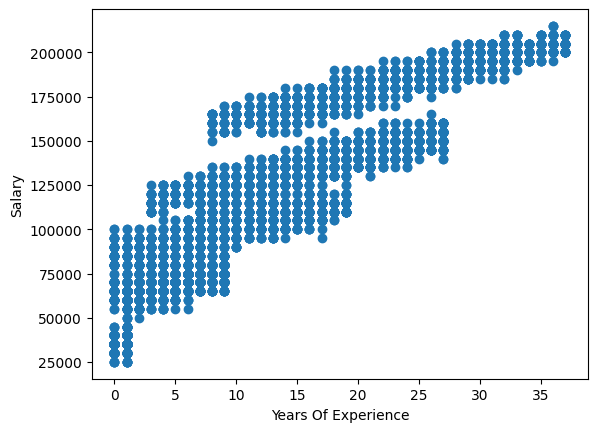

In [13]:
import matplotlib.pyplot as plt

plt.scatter(df["Experience_Years"], df["Salary"])
plt.xlabel("Years Of Experience")
plt.ylabel("Salary")
plt.show()

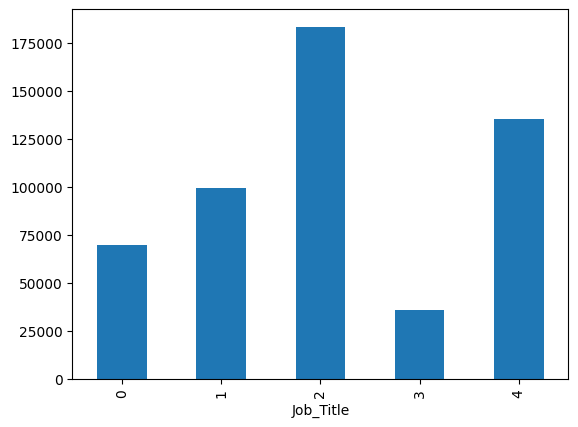

In [14]:
df.groupby("Job_Title")["Salary"].mean().plot(kind="bar")
plt.show()

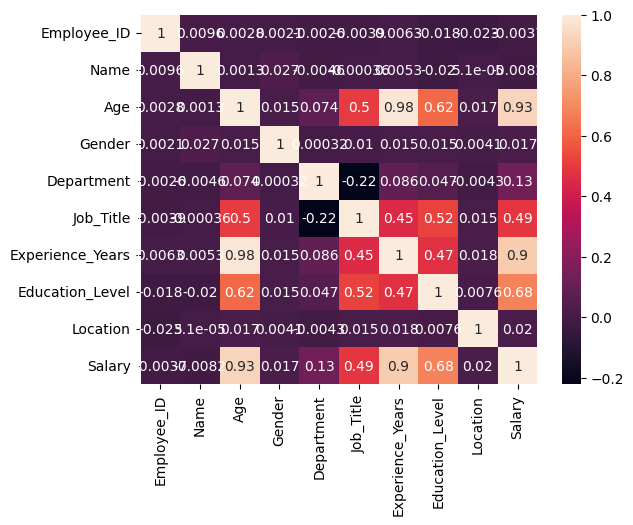

In [15]:
import seaborn as sns

sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True)
plt.show()

In [16]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
# Drop 'Salary' (target) and identifier/less relevant categorical columns
X = df.drop(["Salary", "Employee_ID", "Name", "Department", "Location"], axis=1)
y = df["Salary"]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Features used for training:")
print(X_train.columns)

Features used for training:
Index(['Age', 'Gender', 'Job_Title', 'Experience_Years', 'Education_Level'], dtype='object')


In [17]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X_train, y_train)

RandomForestRegressor()

In [18]:
print(df.dtypes)

Employee_ID         int64
Name                int64
Age                 int64
Gender              int64
Department          int64
Job_Title           int64
Experience_Years    int64
Education_Level     int64
Location            int64
Salary              int64
dtype: object


In [19]:
print(df.columns)

Index(['Employee_ID', 'Name', 'Age', 'Gender', 'Department', 'Job_Title',
       'Experience_Years', 'Education_Level', 'Location', 'Salary'],
      dtype='object')


In [22]:
import pandas as pd # Import pandas to ensure df can be reloaded
from sklearn.preprocessing import LabelEncoder
import IPython.display as display # Ensure display is imported

# IMPORTANT: Reload the DataFrame to ensure categorical columns are in original 'object' dtype
# This ensures LabelEncoder can be fitted correctly on original categories.
# Please verify the path to your CSV file if it's different from what was previously used.
# The path `/Employers_data (1).csv` is based on the last successful load.
df = pd.read_csv('/content/Employers_data.csv')

# Create a dictionary to store label encoders for each categorical column
label_encoders = {}

# Explicitly define the categorical features that need encoding
categorical_features = ['Name', 'Gender', 'Department', 'Job_Title', 'Education_Level', 'Location']

# Apply Label Encoding to each specified categorical column and store the encoder
for col in categorical_features:
    if col in df.columns:
        label_encoders[col] = LabelEncoder() # Create a new encoder for each column
        df[col] = label_encoders[col].fit_transform(df[col])
        print(f"Encoded column '{col}'.")
    else:
        print(f"Warning: Column '{col}' not found in DataFrame during encoding. Skipping.")

# Display the updated dtypes to confirm encoding
print("DataFrame dtypes after label encoding:")
display.display(df.dtypes) # Corrected call to display.display()

Encoded column 'Name'.
Encoded column 'Gender'.
Encoded column 'Department'.
Encoded column 'Job_Title'.
Encoded column 'Education_Level'.
Encoded column 'Location'.
DataFrame dtypes after label encoding:


,0
Employee_ID,int64
Name,int64
Age,int64
Gender,int64
Department,int64
Job_Title,int64
Experience_Years,int64
Education_Level,int64
Location,int64
Salary,int64


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Define features (X) and target (y)
# Drop only 'Salary' to include all other 9 features for training
X = df.drop(["Salary"], axis=1)
y = df["Salary"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor()
model.fit(X_train, y_train)

RandomForestRegressor()

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("R2:", r2_score(y_test, pred))

MAE: 3606.575
RMSE: 4509.726571534022
R2: 0.9903506189273666


In [25]:
model.fit(X_train, y_train)

RandomForestRegressor()

In [26]:
def predict_employee_salary():
    try:
        # --- Collect Inputs for all 9 features ---
        employee_id = int(input("Enter Employee ID (e.g., 101): "))
        if not (1 <= employee_id <= 10000): # Assuming ID range based on original data
            raise ValueError("Employee ID must be within a reasonable range (e.g., 1-10000).")

        # Name (encoded categorical) - This is usually an identifier and not a predictive feature.
        # To get an encoded value, the input name must exist in the original training data.
        # For demonstration, we'll ask for an existing name and encode it.
        name_options = list(label_encoders['Name'].classes_)
        print(f"\nAvailable Names (first 10 for example): {', '.join(name_options[:10])}, ...")
        name_input = input(f"Enter Name from the dataset (e.g., {name_options[0]}): ").strip()
        if name_input not in name_options:
            raise ValueError(f"Invalid Name. Please enter a name that was present in the training data.")
        name_encoded = label_encoders['Name'].transform([name_input])[0]

        age = int(input("Enter Age (e.g., 25): "))
        if not (18 <= age <= 65): # Assuming a reasonable age range
            raise ValueError("Age must be between 18 and 65.")

        # Gender (encoded categorical)
        gender_options = list(label_encoders['Gender'].classes_)
        gender_input = input(f"Enter Gender {tuple(gender_options)}: ").strip()
        if gender_input not in gender_options:
            raise ValueError(f"Invalid Gender. Choose from {tuple(gender_options)}")
        gender_encoded = label_encoders['Gender'].transform([gender_input])[0]

        # Department (encoded categorical)
        department_options = list(label_encoders['Department'].classes_)
        department_input = input(f"Enter Department (e.g., {', '.join(department_options[:5])}, ...): ").strip()
        if department_input not in department_options:
            raise ValueError(f"Invalid Department. Choose from {tuple(department_options)}")
        department_encoded = label_encoders['Department'].transform([department_input])[0]

        # Job Title (encoded categorical)
        job_title_options = list(label_encoders['Job_Title'].classes_)
        job_title_input = input(f"Enter Job Title (e.g., {', '.join(job_title_options[:5])}, ...): ").strip()
        if job_title_input not in job_title_options:
            raise ValueError(f"Invalid Job Title. Please choose from the known job titles: {', '.join(job_title_options)}")
        job_title_encoded = label_encoders['Job_Title'].transform([job_title_input])[0]

        experience_years = int(input("Enter Years of Experience (e.g., 5): "))
        if not (0 <= experience_years <= 40): # Assuming a reasonable experience range
            raise ValueError("Years of Experience must be non-negative and realistic.")

        # Education Level (encoded categorical)
        education_options = list(label_encoders['Education_Level'].classes_)
        education_input = input(f"Enter Education Level {tuple(education_options)}: ").strip()
        if education_input not in education_options:
            raise ValueError(f"Invalid Education Level. Choose from {tuple(education_options)}")
        education_encoded = label_encoders['Education_Level'].transform([education_input])[0]

        # Location (encoded categorical)
        location_options = list(label_encoders['Location'].classes_)
        location_input = input(f"Enter Location (e.g., {', '.join(location_options[:5])}, ...): ").strip()
        if location_input not in location_options:
            raise ValueError(f"Invalid Location. Choose from {tuple(location_options)}")
        location_encoded = label_encoders['Location'].transform([location_input])[0]

        # --- Create DataFrame for Prediction ---
        # Ensure the order of columns matches X_train.columns
        input_data_list = [
            employee_id,
            name_encoded,
            age,
            gender_encoded,
            department_encoded,
            job_title_encoded,
            experience_years,
            education_encoded,
            location_encoded
        ]

        input_data = pd.DataFrame([input_data_list], columns=X_train.columns)

        # --- Make Prediction ---
        predicted_salary = model.predict(input_data)[0]
        print(f"\nPredicted Salary: ${predicted_salary:,.2f}")

    except ValueError as e:
        print(f"Input Error: {e}")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")

### Predicted Employee Salary

The `predict_employee_salary` function uses the features that the model was trained on: 'Age', 'Gender', 'Job Title', 'Years of Experience', and 'Education Level'.

Features like 'Skills score', 'Number of certifications', and 'Company type' are not part of the current model's training data, and therefore, cannot be used for prediction without re-training the model with a dataset that includes these additional features.

Please ensure you run all cells from `xVdPP7OXo_uv` (data loading) through `RdM_FpXwx6On` (model training) before calling the `predict_employee_salary` function to ensure all necessary variables and the trained model are available.

In [29]:
# Call the prediction function to get a predicted salary.
# You will be prompted to enter the required details in the console.
predict_employee_salary()

Enter Employee ID (e.g., 101): 101

Available Names (first 10 for example): Aaron Biderman, Aaron Chaney, Aaron Davis, Aaron Defosses, Aaron Elerson, Aaron Hicks, Aaron Kirch, Aaron Krampitz, Aaron Leonard, Aaron Pennell, ...
Enter Name from the dataset (e.g., Aaron Biderman): Aaron Chaney
Enter Age (e.g., 25): 24
Enter Gender ('Female', 'Male'): Male
Enter Department (e.g., Engineering, Finance, HR, Marketing, Product, ...): HR
Enter Job Title (e.g., Analyst, Engineer, Executive, Intern, Manager, ...): Intern
Enter Years of Experience (e.g., 5): 0
Enter Education Level ('Bachelor', 'Master', 'PhD'): PhD
Enter Location (e.g., Austin, Chicago, New York, San Francisco, Seattle, ...): New York

Predicted Salary: $33,850.00
